In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
data = pd.read_excel("fraud_data_lyst1751134022071.xlsx")
data.head()

,trans_date_trans_time,merchant,category,amt,city,state,lat,long,city_pop,job,dob,trans_num,merch_lat,merch_long,is_fraud
0,2019-04-01 00:58:00,"""Stokes, Christiansen and Sipes""",grocery_net,14.37,Wales,AK,64.7556,-165.6723,145,"""Administrator, education""",1939-09-11 00:00:00,a3806e984cec6ac0096d8184c64ad3a1,65.654142,-164.722603,1
1,2019-04-01 15:06:00,Predovic Inc,shopping_net,966.11,Wales,AK,64.7556,-165.6723,145,"""Administrator, education""",1939-09-11 00:00:00,a59185fe1b9ccf21323f581d7477573f,65.468863,-165.473127,1
2,2019-04-01 22:37:00,Wisozk and Sons,misc_pos,49.61,Wales,AK,64.7556,-165.6723,145,"""Administrator, education""",1939-09-11 00:00:00,86ba3a888b42cd3925881fa34177b4e0,65.347667,-165.914542,1
3,2019-04-01 23:06:00,Murray-Smitham,grocery_pos,295.26,Wales,AK,64.7556,-165.6723,145,"""Administrator, education""",1939-09-11 00:00:00,3a068fe1d856f0ecedbed33e4b5f4496,64.445035,-166.080207,1
4,2019-04-01 23:59:00,Friesen Lt,health_fitness,18.17,Wales,AK,64.7556,-165.6723,145,"""Administrator, education""",1939-09-11 00:00:00,891cdd1191028759dc20dc224347a0ff,65.447094,-165.446843,1


In [5]:
population_mean = data['amt'].mean()
print(f"Population mean: {population_mean}")

Population mean: 124.43007337671327


Sample Mean

In [6]:
sample = data['amt'].sample(n=1000, random_state=42)
sample_mean = sample.mean()
print(f"Sample Mean: {sample_mean}")

Sample Mean: 119.54582999999998


Impact of sample size on sample mean: As the sample size increases, the sample mean becomes a better estimator of the population mean. This is one of the key ideas of the central limit theorem.

In [7]:
sample_sizes = [10, 50, 100, 500, 1000, 5000, 7000]

sample_means = [data['amt'].sample(n=size, random_state=42).mean() for size in sample_sizes]

for size, mean in zip(sample_sizes, sample_means):
    print(f"Sample Size: {size}, Sampe Mean: {mean}")

Sample Size: 10, Sampe Mean: 96.85499999999999
Sample Size: 50, Sampe Mean: 88.3492
Sample Size: 100, Sampe Mean: 81.8355
Sample Size: 500, Sampe Mean: 112.06866000000001
Sample Size: 1000, Sampe Mean: 119.54582999999998
Sample Size: 5000, Sampe Mean: 123.99536800000001
Sample Size: 7000, Sampe Mean: 126.52721


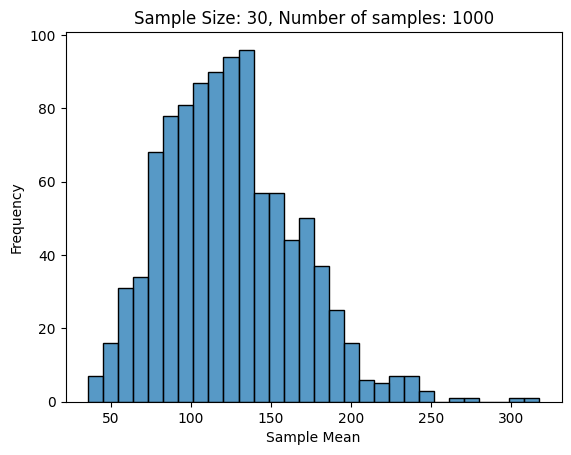

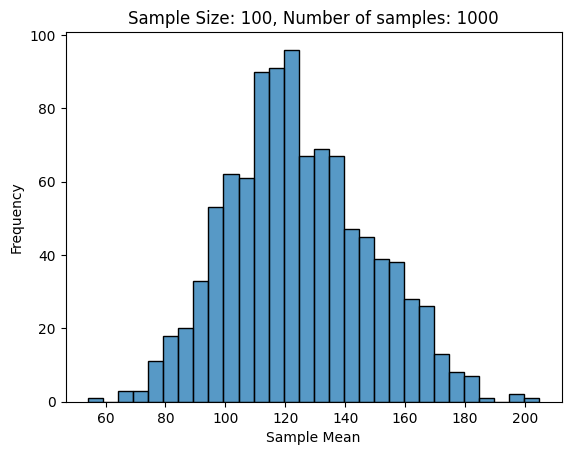

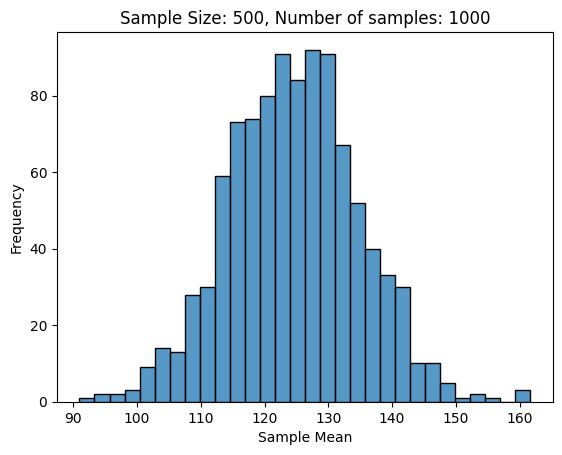

In [10]:
#Function definition
def visualize_clt(data, sample_size, num_samples):
    sample_means = [np.mean(np.random.choice(data, size=sample_size))for _ in range(num_samples)]
    sns.histplot(sample_means, bins=30, edgecolor='black')
    plt.title(f"Sample Size: {sample_size}, Number of samples: {num_samples}")
    plt.xlabel('Sample Mean')
    plt.ylabel('Frequency')
    plt.show()

#Function call    
visualize_clt(data['amt'], sample_size=30, num_samples=1000)
visualize_clt(data['amt'], sample_size=100, num_samples=1000)
visualize_clt(data['amt'], sample_size=500, num_samples=1000)

Sample Mean Vs Sampling Distribution Mean

Sample Mean: The mean of a single sample

Sample Distribution Mean: Mean of all the possible sample means which approximates to the population mean 

In [11]:
sample_means_distribution = [np.mean(np.random.choice(data['amt'], size=100))for _ in range(1000)]
sample_means_distribution

[np.float64(98.21819999999998),
 np.float64(118.65379999999999),
 np.float64(137.71840000000003),
 np.float64(134.873),
 np.float64(121.12070000000001),
 np.float64(135.34099999999998),
 np.float64(89.1145),
 np.float64(95.53939999999999),
 np.float64(151.2292),
 np.float64(90.5987),
 np.float64(94.19329999999998),
 np.float64(149.9888),
 np.float64(113.4699),
 np.float64(115.52609999999999),
 np.float64(128.90210000000002),
 np.float64(114.2987),
 np.float64(121.55959999999999),
 np.float64(116.71279999999999),
 np.float64(165.0483),
 np.float64(114.2342),
 np.float64(131.0508),
 np.float64(132.53960000000004),
 np.float64(125.1048),
 np.float64(170.69299999999998),
 np.float64(104.46590000000002),
 np.float64(95.9004),
 np.float64(142.48090000000002),
 np.float64(136.10829999999999),
 np.float64(109.32870000000003),
 np.float64(113.0081),
 np.float64(90.3396),
 np.float64(122.5558),
 np.float64(115.20300000000002),
 np.float64(146.59650000000002),
 np.float64(99.3884),
 np.float64(14

In [15]:
sampling_distribution_mean = np.mean(sample_means_distribution)
print(sampling_distribution_mean)

125.574386


Standard Deviation: Measure of the spread the individual data points in the population

Vs

Standart Error: Measure the spread of sample measure around the population mean

Text(0, 0.5, 'Standard Error')

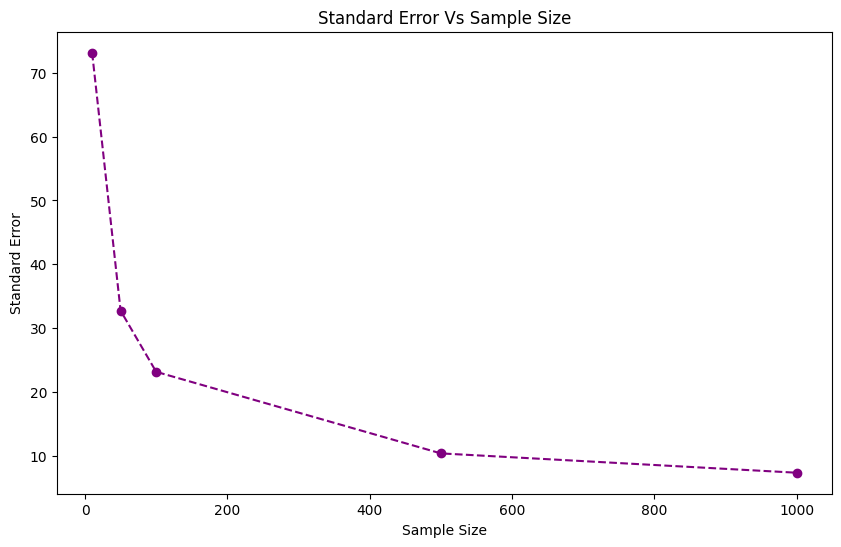

In [26]:
from turtle import color

from matplotlib import markers
from matplotlib.lines import lineStyles


population_std = data['amt'].std()

sample_sizes = [10, 50, 100, 500, 1000]
standard_errors = [population_std/np.sqrt(sample_size) for sample_size in sample_sizes]
plt.figure(figsize=(10, 6))
plt.plot(sample_sizes, standard_errors, marker='o', linestyle='--', color="purple")
plt.title('Standard Error Vs Sample Size')
plt.xlabel('Sample Size')
plt.ylabel('Standard Error')